In [14]:
import pandas as pd

df = pd.read_csv("C:/Users/aswin/Downloads/imdb_top_1000.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [15]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

In [16]:
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

df = df.dropna(subset=['IMDB_Rating', 'Gross', 'Released_Year'])

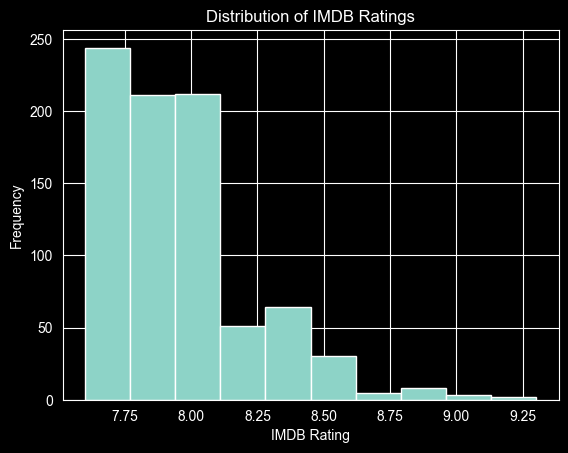

In [17]:
import matplotlib.pyplot as plt

plt.hist(df['IMDB_Rating'], bins=10)
plt.title("Distribution of IMDB Ratings")
plt.xlabel("IMDB Rating")
plt.ylabel("Frequency")
plt.show()

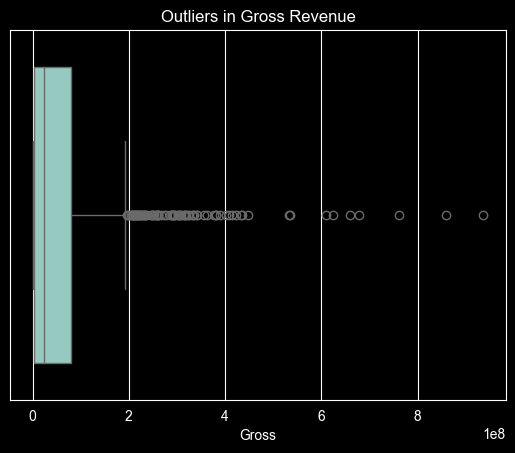

In [18]:
import seaborn as sns

sns.boxplot(x=df['Gross'])
plt.title("Outliers in Gross Revenue")
plt.show()

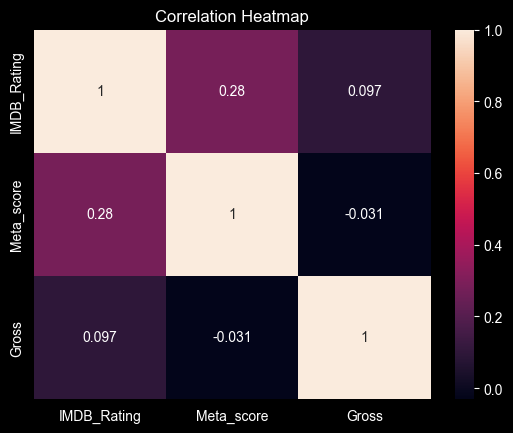

In [19]:
corr = df[['IMDB_Rating', 'Meta_score', 'Gross']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
print("Mean:", df['IMDB_Rating'].mean())
print("Median:", df['IMDB_Rating'].median())
print("Standard Deviation:", df['IMDB_Rating'].std())

Mean: 7.9473493975903615
Median: 7.9
Standard Deviation: 0.28311801891674493


In [21]:
from scipy import stats

old = df[df['Released_Year'] < 2000]['IMDB_Rating']
new = df[df['Released_Year'] >= 2000]['IMDB_Rating']

t_stat, p_val = stats.ttest_ind(old, new)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 4.177713300312799
P-value: 3.25724064907255e-05


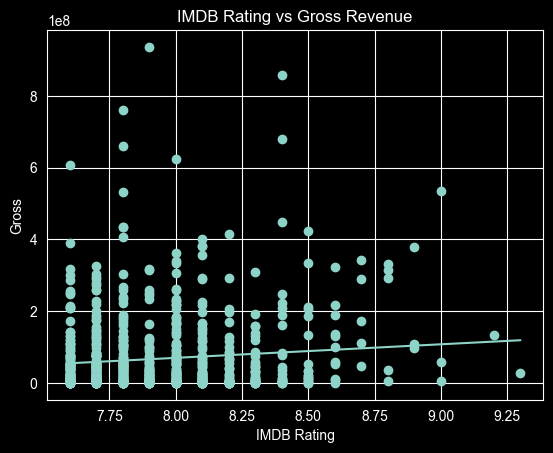

In [22]:
from sklearn.linear_model import LinearRegression

X = df[['IMDB_Rating']]
y = df['Gross']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("IMDB Rating vs Gross Revenue")
plt.xlabel("IMDB Rating")
plt.ylabel("Gross")
plt.show()